In [1]:
import pandas as pd
from pathlib import Path
from unidecode import unidecode

# Rutas del proyecto
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_RAW.mkdir(parents=True, exist_ok=True)

# URL Socrata del SIAD (vista imk8-b6zj) en CSV
# $limit alto para traer todo
siad_url = "https://analisi.transparenciacatalunya.cat/resource/imk8-b6zj.csv?$limit=1500000"

print("Descargando SIAD desde:", siad_url)
siad = pd.read_csv(siad_url)
print("Filas descargadas:", len(siad))

# Guarda una copia cruda en data/raw
out_path = DATA_RAW / "siad_raw.csv"
siad.to_csv(out_path, index=False)
print("Guardado en:", out_path)
siad.head(3)

Descargando SIAD desde: https://analisi.transparenciacatalunya.cat/resource/imk8-b6zj.csv?$limit=1500000
Filas descargadas: 707453
Guardado en: C:\Users\cbelver\Desktop\Projects\P3_CLIMATICAT\ViolenciaDeGenero\data\raw\siad_raw.csv


,siad,sexe,edat,discapacitat,comarca,ambit,estatcivil,llocdenaixement,tipusdefamilia,situaciolaboral,...,derivacioaserveisatencio,tipologiadeconsulta,tipologiadeconsultadeare,tipologia_de_consulta_d_rea_de_salut,tipologiadeconsultadeare_2,tipologiadeconsultadeare_3,tipologiadeconsultadeare_4,tipologiadeconsultadeare_5,atencionsodones,any
0,Ajuntament de Sant Adrià del Besòs,Dones,De 30 a 45 anys,No consta,Barcelonès,Metropolità,Parella de fet,Espanya,No consta,No consta,...,SIAD,Violència,No consta,No consta,No consta,No consta,No consta,Altres,Primera atenció,2019
1,Ajuntament de Sant Adrià del Besòs,Dones,De 30 a 45 anys,No consta,Barcelonès,Metropolità,Casada,Espanya,No consta,No consta,...,Altres,Psicològic,No consta,No consta,No consta,No consta,No consta,Altres,Primera atenció,2019
2,Ajuntament de Sant Adrià del Besòs,Dones,De 30 a 45 anys,No consta,Barcelonès,Metropolità,Soltera,Espanya,No consta,No consta,...,Acolliment i recuperació,Jurídic,No consta,No consta,No consta,No consta,No consta,Altres,Primera atenció,2019


In [2]:
import re
import pandas as pd
from pathlib import Path
from unidecode import unidecode

# Rutas
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROC = PROJECT_ROOT / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)

# Carga
df = pd.read_csv(DATA_RAW / "siad_raw.csv")
print("Filas:", len(df))
print("Columnas:", len(df.columns))
print(sorted(df.columns.tolist())[:25], "...") # primeras 25 ordenadas alfabéticamente

# 1) Intentar detectar una columna territorial
# Vamos a buscar nombres comunes
candidatas = [c for c in df.columns if re.search(
    r"(municip|ciutat|ciudad|localit|poblaci|barri|distric|ens|siad|servei|ajuntament)",
    c, flags=re.I
)]

print("\nPosibles columnas territoriales (candidatas):")
for c in candidatas:
    print(" -", c)

# Escoge la primera candidata como predeterminada
LOCATION_COL = candidatas[0] if candidatas else None
print("\nLOCATION_COL sugerida:", LOCATION_COL)

# Si no encontramos nada, frenamos aquí para decir qué columna usar
if LOCATION_COL is None:
    raise SystemExit("No se ha detectado una columna territorial. Dime cuál usar y seguimos.")

# Vista rápida de valores más frecuentes para confirmar que es territorial
print("\nTOP valores de", LOCATION_COL)
display(df[LOCATION_COL].value_counts(dropna=False).head(15))

# 2) Normalización territorial
def drop_prefixes(txt: str) -> str:
    """Quita prefijos institucionales típicos: 'Ajuntament de', 'Consell Comarcal de', etc."""
    if not isinstance(txt, str):
        return txt
    t = re.sub(r"^\s*(ajuntament|consell comarcal|diputaci[oó]|generalitat|servei|siad|oficina)\s+(de|del|d')\s+", "", txt, flags=re.I)
    return t.strip()

def normalize(txt: str) -> str:
    if not isinstance(txt, str) or not txt.strip():
        return ""
    t = txt.strip().lower()
    t = unidecode(t) # quita acentos
    t = re.sub(r"['`´]", "", t) # apóstrofes
    t = re.sub(r"[^a-z0-9\s\-]", " ", t) # caracteres raros
    t = re.sub(r"^(l|la|el|les|els)\s+", "", t)
    return t

# Aplicar limpieza + normalización
df["_region_raw"] = df[LOCATION_COL].astype(str).map(drop_prefixes)
df["_region_clean"] = df["_region_raw"].map(normalize)

# merge_key final
df["merge_key"] = df["_region_clean"].str.replace(r"\s+", "-", regex=True)

# 3) Conteo por ciudad
g_muni = (
    df.groupby("merge_key", dropna=False)
    .size()
    .reset_index(name="cases_total")
    .sort_values("cases_total", ascending=False)
)
# Etiqueta para mostrar
g_muni["label"] = g_muni["merge_key"].str.replace("-", " ").str.title().str.replace(" De ", " de "). str.replace(" Del ", " del ")

# Guardar
out_muni = DATA_PROC / "mapa_catalunya_municipis.csv"
g_muni.to_csv(out_muni, index=False)
print("\nGuardado:", out_muni, " | filas:", len(g_muni))

# Vista rápida
g_muni.head(10)

Filas: 707453
Columnas: 32
['ambit', 'any', 'atencionsodones', 'canaldentrada', 'comarca', 'derivacioaserveisatencio', 'deteccioviolenciamasclista', 'discapacitat', 'edat', 'estatcivil', 'formadetramitacio', 'llocdenaixement', 'nivelldeformacio', 'professio', 'servei_que_at_n', 'sexe', 'siad', 'situacioeconomica', 'situaciolaboral', 'tipologia_de_consulta_d_rea_de_salut', 'tipologiadeconsulta', 'tipologiadeconsultadeare', 'tipologiadeconsultadeare_2', 'tipologiadeconsultadeare_3', 'tipologiadeconsultadeare_4'] ...

Posibles columnas territoriales (candidatas):
 - siad
 - servei_que_at_n
 - derivacioaserveisatencio

LOCATION_COL sugerida: siad

TOP valores de siad


siad
Ajuntament de l'Hospitalet de Llobregat    28883
Consell Comarcal del Vallès Oriental       24110
Ajuntament de Castelldefels                20396
Ajuntament de Vilafranca del Penedès       18112
Consell Comarcal de la Selva               17599
Ajuntament de Terrassa                     17303
Ajuntament de Sant Boi de Llobregat        17069
Ajuntament de Lleida                       16431
Ajuntament del Prat de Llobregat           15365
Ajuntament de Barcelona                    15292
Ajuntament de Sabadell                     13979
Consell Comarcal del Vallès Occidental     13601
Ajuntament de Santa Coloma de Gramenet     13159
Ajuntament de Sant Joan Despí              12149
Ajuntament de Badalona                     12146
Name: count, dtype: int64


Guardado: C:\Users\cbelver\Desktop\Projects\P3_CLIMATICAT\ViolenciaDeGenero\data\processed\mapa_catalunya_municipis.csv  | filas: 114


,merge_key,cases_total,label
44,lhospitalet-de-llobregat,28883,Lhospitalet de Llobregat
105,valles-oriental,24110,Valles Oriental
21,castelldefels,20396,Castelldefels
111,vilafranca-del-penedes,18112,Vilafranca del Penedes
96,selva,17599,Selva
102,terrassa,17303,Terrassa
84,sant-boi-de-llobregat,17069,Sant Boi de Llobregat
45,lleida,16431,Lleida
71,prat-de-llobregat,15365,Prat de Llobregat
15,barcelona,15292,Barcelona


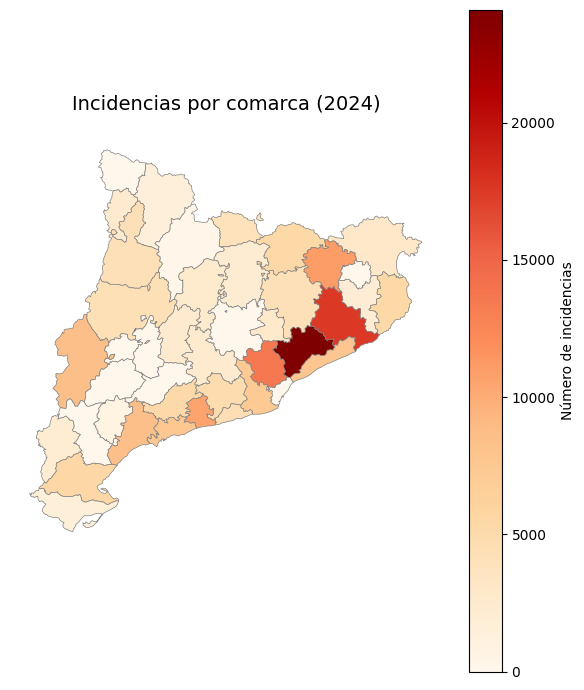

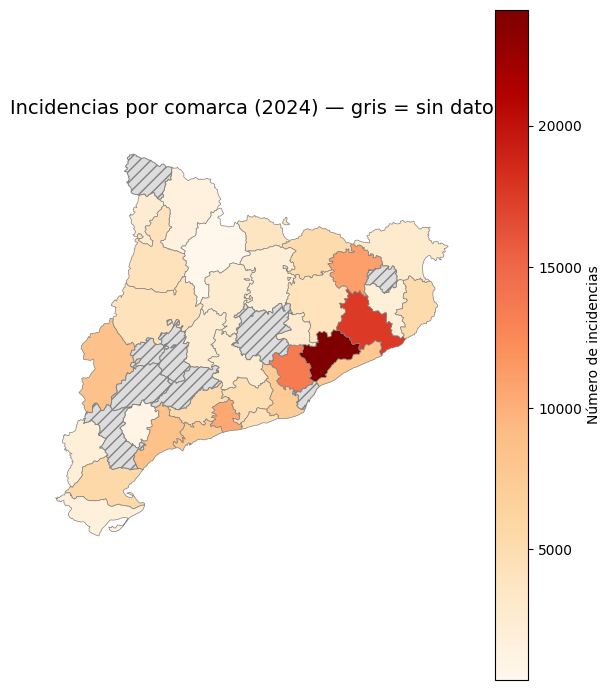

In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata, re

def norm_key(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("utf-8")
    s = s.replace("'", "")
    import re
    s = re.sub(r"[^a-z0-9]+","-", s)
    s = re.sub(r"-+","-", s).strip("-")
    return s

# 1) Cargar
gdf = gpd.read_file("../data/shapes/comarques.geojson")
df  = pd.read_csv("../data/processed/mapa_catalunya_comarcas.csv")

# 2) Normalizar claves
gdf["merge_key"] = gdf["nom"].map(norm_key)
df["merge_key"]  = df["merge_key"].map(norm_key)

# 3) Merge
gdfm = gdf.merge(df[["merge_key","cases_total"]], on="merge_key", how="left")

# ----- Opción B: imputar 0 donde falta -----
gdfm["cases_total_imputed"] = gdfm["cases_total"].fillna(0)

# Para que la barra de color no “colapse” cuando todo sea 0:
vmin, vmax = 0, float(gdfm["cases_total_imputed"].max() or 1)

# 4) Plot principal (con imputación a 0) y giro
fig, ax = plt.subplots(figsize=(6,7))
gdfm.plot(
    column="cases_total_imputed",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="gray",
    legend=True,
    legend_kwds={"label": "Número de incidencias", "orientation": "vertical"},
    vmin=vmin, vmax=vmax,
    ax=ax
)
ax.set_title("Incidencias por comarca (2024)", fontsize=14, pad=15)
ax.axis("off")
ax.invert_yaxis()  # si lo necesitas para girar el mapa 180° (prueba con/sin)

plt.tight_layout()
plt.show()

# ----- Opción C: resaltar “sin dato” encima del mapa -----
# (dibuja el mapa normal con cases_total y superpone las comarcas sin dato en gris claro)
fig, ax = plt.subplots(figsize=(6,7))
base = gdfm.plot(
    column="cases_total",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="gray",
    legend=True,
    legend_kwds={"label": "Número de incidencias", "orientation": "vertical"},
    ax=ax
)
gdfm[gdfm["cases_total"].isna()].plot(
    color="#dddddd", edgecolor="gray", linewidth=0.7, hatch="///", ax=ax
)
ax.set_title("Incidencias por comarca (2024) — gris = sin dato", fontsize=14, pad=15)
ax.axis("off")
ax.invert_yaxis()  # idem
plt.tight_layout()
plt.show()